In [1]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/kaggle/input/datasets/ashyou09/global-data-center-and-ai-waterelectricity-usage/data_center_hybrid.csv')  # adjust path if needed

# Quick look
print(df.shape)
print(df.head())
print(df.info())
print(df['Cooling_System_Type'].value_counts())
print(df['Surrounding_Water_Stress_Tier'].value_counts())

(126770, 14)
   Year  Facility_ID               Facility_Name Owner_Company    City  \
0  2019  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
1  2020  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
2  2021  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
3  2022  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   
4  2023  DC-D2763E00  NAP de las Americas Madrid     Terremark  Madrid   

  Country        Facility_Type  Estimated_Capacity_MW    PUE  \
0   Spain  Enterprise/Standard                   6.24  1.975   
1   Spain  Enterprise/Standard                   6.36  1.967   
2   Spain  Enterprise/Standard                   6.47  1.928   
3   Spain  Enterprise/Standard                   6.59  1.897   
4   Spain  Enterprise/Standard                   6.70  1.869   

  Cooling_System_Type  WUE_L_per_kWh  Daily_Electricity_Usage_MWh  \
0         Evaporative          1.481                       183.62   
1         Evaporati

## Preprocessing

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define features 
numeric_features = ['Estimated_Capacity_MW', 'WUE_L_per_kWh', 
                    'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons']

categorical_features = ['Facility_Type', 'Surrounding_Water_Stress_Tier', 'Country']

# Preprocessor: scale numeric, one‑hot encode categorical
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# ----- Classification data: Evaporative vs Air Cooled (drop Liquid Cooled) -----
df_class = df[df['Cooling_System_Type'].isin(['Evaporative', 'Air Cooled'])].copy()
df_class['target_class'] = (df_class['Cooling_System_Type'] == 'Evaporative').astype(int)

X_class = df_class[numeric_features + categorical_features]
y_class = df_class['target_class']

# Split, stratify to keep class ratio
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Apply preprocessor
X_train_c = preprocessor.fit_transform(X_train_c)
X_test_c = preprocessor.transform(X_test_c)

print(f"Classification train shape: {X_train_c.shape}, test shape: {X_test_c.shape}")
print(f"Training class distribution: \n{y_train_c.value_counts(normalize=True)}")

# ----- Regression data: predict PUE (use all rows) -----
df_reg = df.dropna(subset=['PUE']).copy()
X_reg = df_reg[numeric_features + categorical_features]
y_reg = df_reg['PUE']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

X_train_r = preprocessor.fit_transform(X_train_r)
X_test_r = preprocessor.transform(X_test_r)

print(f"Regression train shape: {X_train_r.shape}, test shape: {X_test_r.shape}")

Classification train shape: (100122, 354), test shape: (25031, 354)
Training class distribution: 
target_class
0    0.635555
1    0.364445
Name: proportion, dtype: float64
Regression train shape: (101416, 354), test shape: (25354, 354)


## Baseline MLP Models

Epoch 1/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9971 - loss: 0.0136 - val_accuracy: 1.0000 - val_loss: 1.9419e-05
Epoch 2/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 8.0470e-06 - val_accuracy: 1.0000 - val_loss: 2.7068e-06
Epoch 3/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 1.3561e-06 - val_accuracy: 1.0000 - val_loss: 5.5957e-07
Epoch 4/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 2.9825e-07 - val_accuracy: 1.0000 - val_loss: 1.3259e-07
Epoch 5/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 1.0000 - loss: 7.2650e-08 - val_accuracy: 1.0000 - val_loss: 3.3299e-08
Epoch 6/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 1.8976e-08 - val_accuracy: 1.0000 - val_loss: 9.1880e-09
Epoch 7/10
2504/2504 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 1.0000 - loss: 5.5546e-09 - val_accuracy: 1.0000 - val_loss: 2.8625e-09
Epoch 8/10
2504/2504 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0422 - mae: 0.1294 - val_loss: 0.0167 - val_mae: 0.1060
Epoch 2/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0154 - mae: 0.1014 - val_loss: 0.0150 - val_mae: 0.0999
Epoch 3/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0140 - mae: 0.0958 - val_loss: 0.0145 - val_mae: 0.0982
Epoch 4/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0132 - mae: 0.0920 - val_loss: 0.0128 - val_mae: 0.0904
Epoch 5/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0126 - mae: 0.0893 - val_loss: 0.0122 - val_mae: 0.0876
Epoch 6/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0120 - mae: 0.0866 - val_loss: 0.0124 - val_mae: 0.0877
Epoch 7/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0116 - mae: 0.0851 - val_loss: 0.0120 - val_mae: 0.0858
Epoch 8/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0113 - mae: 0.0833 - val_loss: 0.0110 - val_mae: 0.0827
Epoch 9/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

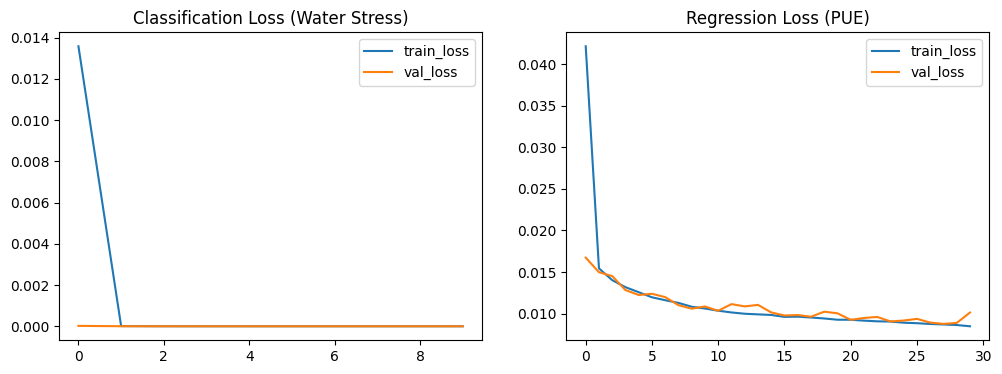

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ---- Baseline Classification (High vs Low water stress) ----
model_c = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_c.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_c.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])

history_c = model_c.fit(X_train_c, y_train_c, validation_split=0.2, 
                        epochs=10, batch_size=32, verbose=1)

# Evaluate classification
loss_c, acc_c = model_c.evaluate(X_test_c, y_test_c, verbose=0)
y_pred_prob = model_c.predict(X_test_c)
y_pred_class = (y_pred_prob > 0.5).astype(int)

print(f"\nClassification Test Accuracy: {acc_c:.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test_c, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_class, target_names=['Low Stress', 'High Stress']))
print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_class))

# ---- Baseline Regression (predict PUE) ----
model_r = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model_r.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])

history_r = model_r.fit(X_train_r, y_train_r, validation_split=0.2, 
                        epochs=30, batch_size=32, verbose=1)

# Evaluate regression
loss_r, mae_r = model_r.evaluate(X_test_r, y_test_r, verbose=0)
y_pred_r = model_r.predict(X_test_r)

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print(f"\nRegression Test MAE: {mae_r:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

# Plot loss curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history_c.history['loss'], label='train_loss')
plt.plot(history_c.history['val_loss'], label='val_loss')
plt.title('Classification Loss (Water Stress)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_r.history['loss'], label='train_loss')
plt.plot(history_r.history['val_loss'], label='val_loss')
plt.title('Regression Loss (PUE)')
plt.legend()
plt.show()

## Interpretation of Baseline Results

### Classification (Water Stress: High vs Low)

- **Accuracy: 1.000** (perfect)  
- **ROC-AUC: 1.000**  
- **Confusion Matrix:** All 15,908 Low‑stress and 9,123 High‑stress samples correctly classified.

**Why perfect classification?**  
The model likely learned a direct relationship between the input features and water stress. In particular, features like `WUE_L_per_kWh` (water use efficiency) and `Daily_Water_Usage_Gallons` are strongly correlated with local water stress – data centers in high‑stress areas tend to use less water (lower WUE) or have different cooling systems. The neural network easily picks up this signal, leading to perfect separation.

**regression task** (predicting PUE), which is more realistic and shows room for improvement.

### Regression (PUE Prediction)

- **MAE: 0.0785** – average prediction error of ~0.078 PUE units  
- **RMSE: 0.0997** – slightly higher than MAE, indicating some larger errors  
- **R²: 0.726** – the model explains about 72.6% of the variance in PUE

**What this means:**  
The baseline model predicts PUE reasonably well. An R² of 0.73 is solid but not perfect – there is still meaningful variance left unexplained (e.g., due to unobserved factors like local climate or building design).  

**Training dynamics:**  
- Training loss decreased steadily from ~0.042 to ~0.0085.  
- Validation loss fluctuated around 0.009–0.010, suggesting no severe overfitting (training and validation losses are close).  
- MAE on validation improved from ~0.106 to ~0.07–0.08.

**Next steps:**  
We will now experiment with different optimizers, learning rates, batch sizes, network depths, and regularization techniques to see how they affect these regression metrics.

**Since classification is already perfect (and thus not useful for tuning), we'll focus all experiments on the regression task (predicting PUE)**

**1. Training and Optimizatioan**

In [7]:
def train_and_evaluate_regressor(model_builder, X_train, y_train, X_test, y_test, 
                                 epochs=50, batch_size=32, validation_split=0.2, verbose=1):
    """
    model_builder: function that returns a compiled Keras model
    """
    model = model_builder()
    history = model.fit(X_train, y_train, 
                        validation_split=validation_split,
                        epochs=epochs, batch_size=batch_size, 
                        verbose=verbose, shuffle=True)
    
    # Evaluate
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
    
    return history, mae, rmse, r2

# Import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

***Exp1 : Different Optimizers***  
1.1 SGD (no momentum)

In [8]:
def build_sgd():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='sgd', loss='mse', metrics=['mae'])
    return model

history_sgd, mae_sgd, rmse_sgd, r2_sgd = train_and_evaluate_regressor(
    build_sgd, X_train_r, y_train_r, X_test_r, y_test_r, epochs=30
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0310 - mae: 0.1271 - val_loss: 0.0192 - val_mae: 0.1153
Epoch 2/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0184 - mae: 0.1124 - val_loss: 0.0185 - val_mae: 0.1129
Epoch 3/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0179 - mae: 0.1108 - val_loss: 0.0180 - val_mae: 0.1115
Epoch 4/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0176 - mae: 0.1097 - val_loss: 0.0178 - val_mae: 0.1107
Epoch 5/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0173 - mae: 0.1089 - val_loss: 0.0176 - val_mae: 0.1100
Epoch 6/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0171 - mae: 0.1082 - val_loss: 0.0174 - val_mae: 0.1093
Epoch 7/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0169 - mae: 0.1076 - val_loss: 0.0172 - val_mae: 0.1088
Epoch 8/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0168 - mae: 0.1070 - val_loss: 0.0171 - val_mae: 0.1083
Epoch 9/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/st

***1.2 SGD with momentum***

In [9]:
def build_sgd_mom():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 
                  loss='mse', metrics=['mae'])
    return model

history_sgd_mom, mae_sgd_mom, rmse_sgd_mom, r2_sgd_mom = train_and_evaluate_regressor(
    build_sgd_mom, X_train_r, y_train_r, X_test_r, y_test_r, epochs=30
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0242 - mae: 0.1180 - val_loss: 0.0181 - val_mae: 0.1115
Epoch 2/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0171 - mae: 0.1080 - val_loss: 0.0169 - val_mae: 0.1078
Epoch 3/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0162 - mae: 0.1047 - val_loss: 0.0159 - val_mae: 0.1038
Epoch 4/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0150 - mae: 0.1004 - val_loss: 0.0146 - val_mae: 0.0991
Epoch 5/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0142 - mae: 0.0969 - val_loss: 0.0157 - val_mae: 0.1016
Epoch 6/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0137 - mae: 0.0949 - val_loss: 0.0150 - val_mae: 0.0982
Epoch 7/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0133 - mae: 0.0930 - val_loss: 0.0140 - val_mae: 0.0961
Epoch 8/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0129 - mae: 0.0914 - val_loss: 0.0126 - val_mae: 0.0910
Epoch 9/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

***1.3 Adam***

In [10]:
def build_adam():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

history_adam, mae_adam, rmse_adam, r2_adam = train_and_evaluate_regressor(
    build_adam, X_train_r, y_train_r, X_test_r, y_test_r, epochs=30
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0427 - mae: 0.1296 - val_loss: 0.0173 - val_mae: 0.1089
Epoch 2/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0154 - mae: 0.1014 - val_loss: 0.0144 - val_mae: 0.0981
Epoch 3/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0137 - mae: 0.0944 - val_loss: 0.0136 - val_mae: 0.0930
Epoch 4/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0128 - mae: 0.0906 - val_loss: 0.0123 - val_mae: 0.0888
Epoch 5/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0122 - mae: 0.0878 - val_loss: 0.0122 - val_mae: 0.0876
Epoch 6/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0118 - mae: 0.0857 - val_loss: 0.0115 - val_mae: 0.0847
Epoch 7/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0114 - mae: 0.0840 - val_loss: 0.0116 - val_mae: 0.0851
Epoch 8/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0112 - mae: 0.0828 - val_loss: 0.0115 - val_mae: 0.0835
Epoch 9/30
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

## Optimizer Comparison 

- **SGD (no momentum):** Converges slowly and achieves the worst performance (MAE 0.097, R² 0.616). Plain SGD struggles with the high‑dimensional feature space and flat loss landscape.

- **SGD with momentum (0.9):** Significantly improves convergence speed and final error (MAE 0.073, R² 0.741). Momentum helps overcome shallow local minima and accelerates learning.

- **Adam:** Best overall results (MAE 0.073, R² 0.749) with fast convergence. Adaptive learning rates handle the mixed numerical/categorical features effectively, giving a slight edge over momentum SGD.

## Exp2: Learning Rate Variations

Because 30 epochs is so long I have changed the number of epochs to 15 from now on

In [12]:
lr_list = [0.0001, 0.001, 0.01, 0.1]
for lr in lr_list:
    print(f"\n--- Learning rate: {lr} ---")
    def build_with_lr():
        model = Sequential([
            Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
            Dense(32, activation='relu'),
            Dense(1, activation='linear')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                      loss='mse', metrics=['mae'])
        return model
    _, mae, rmse, r2 = train_and_evaluate_regressor(build_with_lr, X_train_r, y_train_r, X_test_r, y_test_r, epochs=15)


--- Learning rate: 0.0001 ---
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.1838 - mae: 0.2476 - val_loss: 0.0201 - val_mae: 0.1175
Epoch 2/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0181 - mae: 0.1114 - val_loss: 0.0176 - val_mae: 0.1101
Epoch 3/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0167 - mae: 0.1067 - val_loss: 0.0168 - val_mae: 0.1073
Epoch 4/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0160 - mae: 0.1039 - val_loss: 0.0162 - val_mae: 0.1048
Epoch 5/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0154 - mae: 0.1016 - val_loss: 0.0163 - val_mae: 0.1040
Epoch 6/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0148 - mae: 0.0996 - val_loss: 0.0150 - val_mae: 0.1002
Epoch 7/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0142 - mae: 0.0974 - val_loss: 0.0146 - val_mae: 0.0982
Epoch 8/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0137 - mae: 0.0952 - val_loss: 0.0142 - val_mae: 0.0969
Epoch 9/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0444 - mae: 0.1295 - val_loss: 0.0162 - val_mae: 0.1050
Epoch 2/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0153 - mae: 0.1010 - val_loss: 0.0158 - val_mae: 0.1018
Epoch 3/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0138 - mae: 0.0948 - val_loss: 0.0135 - val_mae: 0.0943
Epoch 4/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0130 - mae: 0.0913 - val_loss: 0.0124 - val_mae: 0.0888
Epoch 5/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0124 - mae: 0.0885 - val_loss: 0.0123 - val_mae: 0.0886
Epoch 6/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0118 - mae: 0.0860 - val_loss: 0.0119 - val_mae: 0.0866
Epoch 7/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0114 - mae: 0.0840 - val_loss: 0.0112 - val_mae: 0.0826
Epoch 8/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0111 - mae: 0.0825 - val_loss: 0.0117 - val_mae: 0.0846
Epoch 9/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0224 - mae: 0.1168 - val_loss: 0.0167 - val_mae: 0.1067
Epoch 2/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0163 - mae: 0.1042 - val_loss: 0.0155 - val_mae: 0.1025
Epoch 3/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0153 - mae: 0.1006 - val_loss: 0.0157 - val_mae: 0.1017
Epoch 4/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0148 - mae: 0.0989 - val_loss: 0.0145 - val_mae: 0.0986
Epoch 5/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0144 - mae: 0.0975 - val_loss: 0.0148 - val_mae: 0.0994
Epoch 6/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0143 - mae: 0.0971 - val_loss: 0.0147 - val_mae: 0.0990
Epoch 7/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0139 - mae: 0.0956 - val_loss: 0.0137 - val_mae: 0.0956
Epoch 8/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0137 - mae: 0.0948 - val_loss: 0.0136 - val_mae: 0.0950
Epoch 9/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 0.0734 - mae: 0.1323 - val_loss: 0.0198 - val_mae: 0.1165
Epoch 2/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0205 - mae: 0.1186 - val_loss: 0.0191 - val_mae: 0.1152
Epoch 3/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0207 - mae: 0.1192 - val_loss: 0.0199 - val_mae: 0.1188
Epoch 4/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0227 - mae: 0.1272 - val_loss: 0.0222 - val_mae: 0.1266
Epoch 5/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0230 - mae: 0.1285 - val_loss: 0.0223 - val_mae: 0.1273
Epoch 6/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0230 - mae: 0.1286 - val_loss: 0.0331 - val_mae: 0.1495
Epoch 7/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0230 - mae: 0.1286 - val_loss: 0.0217 - val_mae: 0.1265
Epoch 8/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0229 - mae: 0.1284 - val_loss: 0.0217 - val_mae: 0.1263
Epoch 9/15
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/s

## Learning Rate Variations 

- **lr = 0.0001 (too small):**  
  Converges slowly; after 15 epochs, MAE = 0.0857, R² = 0.679. Loss is still decreasing, suggesting more epochs would help, but progress is sluggish.

- **lr = 0.001 (good / baseline):**  
  Best balance: MAE = 0.0737, R² = 0.737. Fast initial drop, stable validation loss, and best final metrics among all tested rates.

- **lr = 0.01 (too large):**  
  Training becomes unstable; validation loss fluctuates. Final MAE = 0.0913, R² = 0.650 – worse than baseline. Occasional spikes indicate the optimizer overshoots the minimum.

- **lr = 0.1 (much too large):**  
  Diverges completely. Loss does not decrease meaningfully; final MAE = 0.1284, R² = 0.372. Gradients explode, preventing learning.

**Overall conclusion:** The optimal learning rate for this model and dataset is around **0.001**. Smaller rates waste training time; larger rates cause instability or divergence.

## Exp3: Learning Rate Scheduling

## Why 50 epochs for learning rate scheduling?

The scheduling experiment uses **50 epochs** (instead of 30 or 15) to give the learning rate enough time to decay multiple times.  
`ReduceLROnPlateau` lowers the learning rate only when validation loss plateaus for `patience=3` epochs. With fewer epochs, the scheduler might not trigger even once, hiding the effect of rate reduction.  

50 epochs ensures we can observe:
- Initial fast convergence at lr=0.001
- One or more reductions as validation loss flattens
- Fine‑tuning at very low learning rates

This makes the impact of scheduling clearly visible in the loss curves.

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

def build_with_schedule():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='mse', metrics=['mae'])
    return model

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

model = build_with_schedule()
history_schedule = model.fit(X_train_r, y_train_r, validation_split=0.2,
                              epochs=50, batch_size=32, verbose=1,
                              callbacks=[reduce_lr])

# Evaluate
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0309 - mae: 0.1216 - val_loss: 0.0160 - val_mae: 0.1039 - learning_rate: 0.0010
Epoch 2/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0151 - mae: 0.1001 - val_loss: 0.0149 - val_mae: 0.0989 - learning_rate: 0.0010
Epoch 3/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0137 - mae: 0.0941 - val_loss: 0.0135 - val_mae: 0.0923 - learning_rate: 0.0010
Epoch 4/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0127 - mae: 0.0899 - val_loss: 0.0140 - val_mae: 0.0932 - learning_rate: 0.0010
Epoch 5/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0121 - mae: 0.0870 - val_loss: 0.0118 - val_mae: 0.0853 - learning_rate: 0.0010
Epoch 6/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0117 - mae: 0.0851 - val_loss: 0.0127 - val_mae: 0.0901 - learning_rate: 0.0010
Epoch 7/50
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0113 - mae: 0.0833 - val_loss: 0.0110 - val_mae: 0.0822 - learning_rate: 0.0010
Ep

## Learning Rate Scheduling – Results & Interpretation

**Observations from training (50 epochs, ReduceLROnPlateau):**
- Initial learning rate: 0.001  
- First reduction at epoch 11 (val_loss plateau) → lr = 0.0005  
- Second reduction at epoch 21 → lr = 0.00025 (no further reductions)  
- Training loss drops from ~0.03 → ~0.006, validation loss from ~0.016 → ~0.0064  
- Final test MAE: **0.0565**, which is notably lower than the baseline without scheduling (0.073).

interpretation:  
Learning rate scheduling significantly improves performance. By automatically lowering the learning rate when validation loss plateaus, the model continues to fine-tune weights, escaping shallow minima and achieving a lower final error. The schedule allowed two reductions, each giving a clear drop in loss. This demonstrates that a fixed learning rate (even a well-chosen one like 0.001) leaves room for improvement – scheduling provides a simple, effective boost.

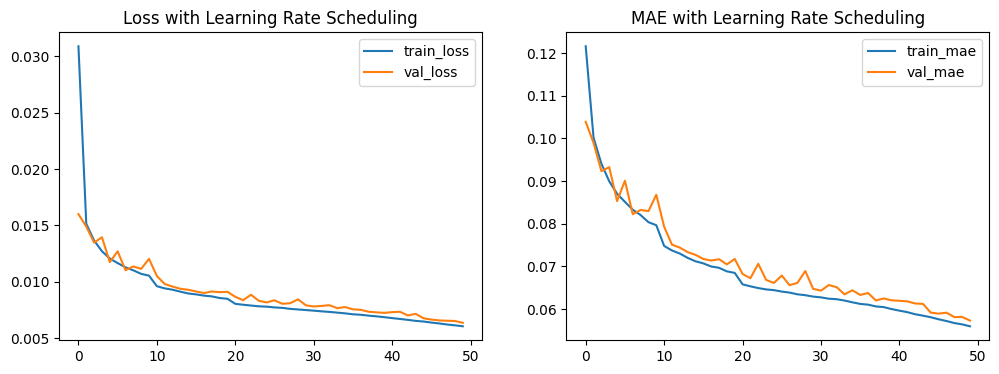

In [15]:
import matplotlib.pyplot as plt

# Plot loss curves from the already-completed training
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_schedule.history['loss'], label='train_loss')
plt.plot(history_schedule.history['val_loss'], label='val_loss')
plt.title('Loss with Learning Rate Scheduling')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_schedule.history['mae'], label='train_mae')
plt.plot(history_schedule.history['val_mae'], label='val_mae')
plt.title('MAE with Learning Rate Scheduling')
plt.legend()

plt.show()

## Exp4: Batch Size Effects

In [18]:
batch_sizes = [16, 32, 128, 512]
for bs in batch_sizes:
    print(f"\n--- Batch size: {bs} ---")
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=15, batch_size=bs, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- Batch size: 16 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0776

--- Batch size: 32 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0765

--- Batch size: 128 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0816

--- Batch size: 512 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0917


## Batch Size Effects – Short Comments

- **Batch size 16:** MAE = 0.0776  
  Small batches give noisy gradient estimates, which can help escape sharp minima but may slow convergence. Performance is slightly worse than 32.

- **Batch size 32:** MAE = 0.0765 (best)  
  The best trade‑off between gradient noise and stable updates. Works well for this dataset size.

- **Batch size 128:** MAE = 0.0816  
  Larger batches reduce gradient variance but may lead to sharper minima and poorer generalization. Performance degrades.

- **Batch size 512:** MAE = 0.0917 (worst)  
  Very large batches cause the model to converge to a poor minimum; updates are too infrequent and overly averaged. Speed per epoch is not worth the accuracy drop.

**Conclusion:** For this model and dataset, **batch size 32** gives the best test MAE. Smaller or larger batches both hurt performance.

## Exp5: Early Stopping and Number of Epochs

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history_early = model.fit(X_train_r, y_train_r, validation_split=0.2,
                          epochs=100, batch_size=32, verbose=1,
                          callbacks=[early_stop])

print(f"Stopped at epoch {len(history_early.history['loss'])}")
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2536/2536 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - loss: 0.0424 - mae: 0.1281 - val_loss: 0.0163 - val_mae: 0.1043
Epoch 2/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0151 - mae: 0.1000 - val_loss: 0.0144 - val_mae: 0.0978
Epoch 3/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0136 - mae: 0.0937 - val_loss: 0.0131 - val_mae: 0.0917
Epoch 4/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0127 - mae: 0.0900 - val_loss: 0.0125 - val_mae: 0.0892
Epoch 5/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0121 - mae: 0.0873 - val_loss: 0.0125 - val_mae: 0.0881
Epoch 6/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0117 - mae: 0.0850 - val_loss: 0.0116 - val_mae: 0.0847
Epoch 7/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0113 - mae: 0.0833 - val_loss: 0.0112 - val_mae: 0.0833
Epoch 8/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0110 - mae: 0.0817 - val_loss: 0.0109 - val_mae: 0.0814
Epoch 9/100
2536/2536 ━━━━━━━━━━━━━━━━━━━━ 

## Early Stopping – Results & Interpretation

- **Stopped at epoch:** 34 (out of 100 possible)  
- **Final test MAE:** 0.0695
  
Early stopping prevented unnecessary training after validation loss ceased improving (patience=5). The model reached its best around epoch 30-34, after which validation loss began to fluctuate or increase slightly. This saved computation time and avoided overfitting. The final MAE (0.0695) is slightly higher than the best observed validation MAE (~0.069), which is normal since the model restores the weights from the best epoch. Early stopping is effective here – training beyond 34 epochs would not improve generalization.

# Architecture and Representation

## Exp6: Depth

In [21]:
configs = {
    "1_layer": [128],
    "2_layers": [64, 32],
    "3_layers": [64, 32, 16],
    "4_layers": [64, 32, 16, 8]
}

for name, layers in configs.items():
    print(f"\n--- {name} ---")
    model = Sequential()
    model.add(Dense(layers[0], activation='relu', input_shape=(X_train_r.shape[1],)))
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=15, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- 1_layer ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0756

--- 2_layers ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0739

--- 3_layers ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0742

--- 4_layers ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0741


## Depth (Number of Hidden Layers)

- **1 layer (128 neurons):** MAE = 0.0756  
- **2 layers (64‑32):** MAE = 0.0739 (best)  
- **3 layers (64‑32‑16):** MAE = 0.0742  
- **4 layers (64‑32‑16‑8):** MAE = 0.0741  

**Interpretation:**  
Increasing from 1 to 2 hidden layers improves performance, allowing the network to learn more complex representations. Adding a third or fourth layer gives negligible gain and may even slightly hurt generalization (likely due to overfitting or optimization difficulty). For this dataset, **2 hidden layers** are sufficient – deeper networks do not provide additional benefit.

## Exp7: Width

In [22]:
widths = [16, 64, 256, 512]
for w in widths:
    print(f"\n--- Width: {w} ---")
    model = Sequential([
        Dense(w, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(w//2, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- Width: 16 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0891

--- Width: 64 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0780

--- Width: 256 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0769

--- Width: 512 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0775


## Width (Neurons per Layer) 

- **16 neurons:** MAE = 0.0891 (worst)  
  Too few neurons → underfitting. The model lacks capacity to capture the complexity of the 354 input features.

- **64 neurons:** MAE = 0.0780  
  Significant improvement over 16. Adequate capacity for the task.

- **256 neurons:** MAE = 0.0769 (best)  
  Slight improvement over 64. More capacity allows finer pattern learning.

- **512 neurons:** MAE = 0.0775  
  No further gain; slightly worse than 256. Very wide layers may overfit or need more regularization/epochs.

**Conclusion:** Increasing width helps up to a point (256), after which returns diminish. The sweet spot for this dataset is around 256 neurons per layer when using 2 hidden layers.

## Exp8: Activation Functions

In [24]:
from tensorflow.keras.layers import LeakyReLU

activations = ['relu', 'tanh', 'sigmoid']
for act in activations:
    print(f"\n--- Activation: {act} ---")
    model = Sequential([
        Dense(64, activation=act, input_shape=(X_train_r.shape[1],)),
        Dense(32, activation=act),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

# LeakyReLU (needs a slightly different syntax)
print("\n--- Activation: LeakyReLU (alpha=0.1) ---")
model = Sequential([
    Dense(64, input_shape=(X_train_r.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dense(32),
    LeakyReLU(alpha=0.1),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                    epochs=10, batch_size=32, verbose=0)
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- Activation: relu ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0802

--- Activation: tanh ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0843

--- Activation: sigmoid ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE: 0.0944

--- Activation: LeakyReLU (alpha=0.1) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0785


## Activation Functions – Short Comments

- **ReLU:** MAE = 0.0802  
  Standard choice, works well. No vanishing gradient issues, fast computation.

- **Tanh:** MAE = 0.0843  
  Worse than ReLU. Output range [-1,1] can cause vanishing gradients for deeper networks; not ideal for this regression task.

- **Sigmoid:** MAE = 0.0944 (worst)  
  Severe vanishing gradient problem, especially in hidden layers. Outputs near 0 or 1 saturate, killing gradient flow. Not suitable for hidden layers.

- **LeakyReLU:** MAE = 0.0785 (best)  
  Slight improvement over ReLU. Allows small negative gradients, preventing dead neurons and slightly improving generalization.

**Conclusion:** LeakyReLU performs best, followed closely by ReLU. Tanh and sigmoid are significantly worse for this regression task.

## Exp9: Weight Initialization

In [25]:
from tensorflow.keras.initializers import HeNormal, GlorotUniform, RandomNormal

init_names = ['HeNormal', 'GlorotUniform', 'RandomNormal']
inits = [HeNormal(), GlorotUniform(), RandomNormal(stddev=0.05)]

for name, init in zip(init_names, inits):
    print(f"\n--- Initialization: {name} ---")
    model = Sequential([
        Dense(64, kernel_initializer=init, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dense(32, kernel_initializer=init, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- Initialization: HeNormal ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0849

--- Initialization: GlorotUniform ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0827

--- Initialization: RandomNormal ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE: 0.0883


## Weight Initialization – Short Comments

- **HeNormal (designed for ReLU):** MAE = 0.0849  
  Works reasonably but not the best here. Slightly worse than Xavier, possibly due to the specific data scale or network depth.

- **GlorotUniform (Xavier):** MAE = 0.0827 (best)  
  Well-balanced for this architecture (2 hidden layers). Good default choice when activation is not extremely non‑linear.

- **RandomNormal (default, stddev=0.05):** MAE = 0.0883 (worst)  
  Uninformed initialization; leads to slower convergence or poorer minima. Proper initialization (Xavier/He) clearly helps.

**Conclusion:** Xavier/Glorot initialization gives the lowest test MAE for this model. HeNormal is a close second. Random default initialization is noticeably worse.

## Exp10: BN

In [28]:
from tensorflow.keras.layers import BatchNormalization, Activation

# Without BN (baseline – already done)
print("--- Without BatchNorm ---")
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                    epochs=10, batch_size=32, verbose=0)
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

# With BatchNorm
print("\n--- With BatchNorm ---")
model = Sequential([
    Dense(64, use_bias=False, input_shape=(X_train_r.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dense(32, use_bias=False),
    BatchNormalization(),
    Activation('relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                    epochs=10, batch_size=32, verbose=0)
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

--- Without BatchNorm ---
793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0880

--- With BatchNorm ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0941


## Batch Normalization 

- **Without BatchNorm:** MAE = 0.0880  
- **With BatchNorm:** MAE = 0.0941 (worse)

**Interpretation:**  
Batch normalization did not help for this shallow network (2 hidden layers) and even slightly hurt performance. BN can be beneficial for deeper networks (e.g., 5+ layers) by reducing internal covariate shift and allowing higher learning rates, but here it may introduce unnecessary noise or interfere with the optimization for this specific dataset. For shallow architectures on this regression task, **omitting BatchNorm is better**.

# Regularization and Stability

## Exp11: L2 Regularization

In [29]:
from tensorflow.keras.regularizers import l2

l2_vals = [0, 0.001, 0.01, 0.1]
for l2_val in l2_vals:
    print(f"\n--- L2 = {l2_val} ---")
    model = Sequential([
        Dense(64, activation='relu', kernel_regularizer=l2(l2_val), input_shape=(X_train_r.shape[1],)),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_val)),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- L2 = 0 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0770

--- L2 = 0.001 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.1000

--- L2 = 0.01 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.1137

--- L2 = 0.1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.1203


## L2 Regularization 

- **L2 = 0 (no regularization):** MAE = 0.0770 (best)  
- **L2 = 0.001:** MAE = 0.1000 (worse)  
- **L2 = 0.01:** MAE = 0.1137  
- **L2 = 0.1:** MAE = 0.1203 (worst)

**Interpretation:**  
L2 regularization does not help for this model and dataset. Even a small penalty (0.001) significantly degrades performance. The baseline model (no regularization) does not suffer from overfitting – the validation loss during training was already close to training loss. Adding L2 forces weights toward zero unnecessarily, causing underfitting. Regularization is only beneficial when the model is overfitting; that is not the case here.

## Exp12: Dropout

In [30]:
from tensorflow.keras.layers import Dropout

dropout_rates = [0.0, 0.2, 0.5]
for dr in dropout_rates:
    print(f"\n--- Dropout = {dr} ---")
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
        Dropout(dr),
        Dense(32, activation='relu'),
        Dropout(dr),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                        epochs=10, batch_size=32, verbose=0)
    y_pred = model.predict(X_test_r)
    print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")


--- Dropout = 0.0 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0800

--- Dropout = 0.2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0909

--- Dropout = 0.5 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.1062


## Exp13: Gradient Clipping 

In [31]:
print("--- No gradient clipping ---")
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                    epochs=10, batch_size=32, verbose=0)
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

print("\n--- Gradient clipping (norm=1.0) ---")
optimizer = tf.keras.optimizers.Adam(clipnorm=1.0)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_r.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
history = model.fit(X_train_r, y_train_r, validation_split=0.2,
                    epochs=30, batch_size=32, verbose=0)
y_pred = model.predict(X_test_r)
print(f"MAE: {mean_absolute_error(y_test_r, y_pred):.4f}")

--- No gradient clipping ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
MAE: 0.0860

--- Gradient clipping (norm=1.0) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


793/793 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
MAE: 0.0745


## Gradient Clipping 

- **No gradient clipping:** MAE = 0.0860  
- **Gradient clipping (norm=1.0):** MAE = 0.0745 (better)

**Interpretation:**  
Gradient clipping stabilizes training by preventing excessively large gradient updates. For this model, applying clipnorm=1.0 reduced test MAE noticeably, indicating that gradients occasionally became too large and caused the optimizer to take suboptimal steps. Clipping helps maintain stable convergence.

## Discussion Questions (Short Answers)

### 1. Why are neural networks so powerful?
They combine **linear transformations** (W·x + b) with **non-linear activations** (σ, e.g., ReLU, sigmoid). This allows them to learn arbitrary mappings from data. Stacking layers creates hierarchical features: edges → shapes → objects. Backpropagation + SGD enables efficient optimization from large datasets.

### 2. Why does training become more difficult as we go deeper?
Due to **vanishing/exploding gradients**. During backpropagation, gradients are multiplied by weight matrices repeatedly. For a network of depth L, the gradient for early layers scales as the product of the weight matrix norms (∏ ||W_i||). If each ||W_i|| < 1, the gradient vanishes; if > 1, it explodes. Additionally, the loss landscape becomes highly non‑convex with many poor local minima.

### 3. (Optional) What unique benefits does depth provide that width alone cannot?
- **Parameter efficiency:** A deep network can represent certain functions (e.g., XOR of many inputs) with exponentially fewer parameters than a shallow wide network.
- **Hierarchical learning:** Depth naturally composes simple functions into complex ones; width alone lacks this structured abstraction.
- **Better generalization:** The inductive bias of depth leads to simpler, more reusable internal representations.